## Setup and Dependencies
Installing and importing all required libraries for data processing, image loading, augmentation, and model training.


In [4]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 56.6 MB/s eta 0:00:00


In [5]:
#Necessary libraries
import os
import pydicom
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import animation, rc
import pandas as pd
import glob
import json
import collections
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_score, recall_score
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model

## Data Acquisition
Downloading the RSNA 2024 Lumbar Spine Degenerative Classification dataset from Kaggle.
Dataset contains 32GB of DICOM MRI images across ~1,900 studies.
Note: You will need a Kaggle account and must accept the competition rules at https://www.kaggle.com/competitions/rsna-2024-lumbar-spine-degenerative-classification before downloading.


In [6]:
# Setup Kaggle credentials from Colab Secrets
from google.colab import userdata
import os

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

In [ ]:
# Step 1: Install Kaggle package
!pip install kaggle

# Step 2: Download the dataset
!kaggle competitions download -c rsna-2024-lumbar-spine-degenerative-classification

# Step 3: Unzip the dataset
!unzip rsna-2024-lumbar-spine-degenerative-classification.zip -d /content/RSNAdata

Streaming output truncated to the last 5000 lines.
  inflating: /content/RSNAdata/train_images/885894528/2509467535/43.dcm  
  inflating: /content/RSNAdata/train_images/885894528/2509467535/44.dcm  
  inflating: /content/RSNAdata/train_images/885894528/2509467535/45.dcm  
  inflating: /content/RSNAdata/train_images/885894528/2509467535/46.dcm  
  inflating: /content/RSNAdata/train_images/885894528/2509467535/47.dcm  
  inflating: /content/RSNAdata/train_images/885894528/2509467535/48.dcm  
  inflating: /content/RSNAdata/train_images/885894528/2509467535/49.dcm  
  inflating: /content/RSNAdata/train_images/885894528/2509467535/5.dcm  
  inflating: /content/RSNAdata/train_images/885894528/2509467535/50.dcm  
  inflating: /content/RSNAdata/train_images/885894528/2509467535/6.dcm  
  inflating: /content/RSNAdata/train_images/885894528/2509467535/7.dcm  
  inflating: /content/RSNAdata/train_images/885894528/2509467535/8.dcm  
  inflating: /content/RSNAdata/train_images/885894528/2509467535/

## Data Loading and Preprocessing
Loading CSV metadata files and DICOM images. Labels are reshaped from wide to long format and merged with image coordinates and series descriptions to create a unified training dataframe.

In [ ]:
#Data Loading and Preprocessing
train_path = '/content/RSNAdata/'
test_path = '/content/RSNAdata/test_images/'
train_images = train_path + "train_images/"
train  = pd.read_csv(train_path + 'train.csv')
label = pd.read_csv(train_path + 'train_label_coordinates.csv')
train_desc  = pd.read_csv(train_path + 'train_series_descriptions.csv')
test_desc   = pd.read_csv(train_path + 'test_series_descriptions.csv')
sub         = pd.read_csv(train_path + 'sample_submission.csv')

In [ ]:
# Function to reshape a single row of the DataFrame
def reshape_row(row):
    data = {'study_id': [], 'condition': [], 'level': [], 'severity': []}

    for column, value in row.items():
        if column not in ['study_id', 'series_id', 'instance_number', 'x', 'y', 'series_description']:
            parts = column.split('_')
            condition = ' '.join([word.capitalize() for word in parts[:-2]])
            level = parts[-2].capitalize() + '/' + parts[-1].capitalize()
            data['study_id'].append(row['study_id'])
            data['condition'].append(condition)
            data['level'].append(level)
            data['severity'].append(value)

    return pd.DataFrame(data)

# Reshape the DataFrame for all rows
new_train_df = pd.concat([reshape_row(row) for _, row in train.iterrows()], ignore_index=True)

new_train_df.head(5)

,study_id,condition,level,severity
0,4003253,Spinal Canal Stenosis,L1/L2,Normal/Mild
1,4003253,Spinal Canal Stenosis,L2/L3,Normal/Mild
2,4003253,Spinal Canal Stenosis,L3/L4,Normal/Mild
3,4003253,Spinal Canal Stenosis,L4/L5,Normal/Mild
4,4003253,Spinal Canal Stenosis,L5/S1,Normal/Mild


In [ ]:
# Merge the DataFrames on the common columns
merged_df = pd.merge(new_train_df, label, on=['study_id', 'condition', 'level'], how='inner')
# Merge the dataframes on the common columns 'series_id' and 'study_id'
final_merged_df = pd.merge(merged_df, train_desc, on=['series_id','study_id'], how='inner')
# Display the first few rows of the final merged dataframe
final_merged_df.head(5)

,study_id,condition,level,severity,series_id,instance_number,x,y,series_description
0,4003253,Spinal Canal Stenosis,L1/L2,Normal/Mild,702807833,8,322.831858,227.964602,Sagittal T2/STIR
1,4003253,Spinal Canal Stenosis,L2/L3,Normal/Mild,702807833,8,320.571429,295.714286,Sagittal T2/STIR
2,4003253,Spinal Canal Stenosis,L3/L4,Normal/Mild,702807833,8,323.030303,371.818182,Sagittal T2/STIR
3,4003253,Spinal Canal Stenosis,L4/L5,Normal/Mild,702807833,8,335.292035,427.327434,Sagittal T2/STIR
4,4003253,Spinal Canal Stenosis,L5/S1,Normal/Mild,702807833,8,353.415929,483.964602,Sagittal T2/STIR


In [ ]:
# Create the row_id column
final_merged_df['row_id'] = (
    final_merged_df['study_id'].astype(str) + '_' +
    final_merged_df['condition'].str.lower().str.replace(' ', '_') + '_' +
    final_merged_df['level'].str.lower().str.replace('/', '_')
)

# Create the image_path column
final_merged_df['image_path'] = (
    f'{train_path}/train_images/' +
    final_merged_df['study_id'].astype(str) + '/' +
    final_merged_df['series_id'].astype(str) + '/' +
    final_merged_df['instance_number'].astype(str) + '.dcm'
)

# Note: Check image path, since there's 1 instance id, for 1 image, but there's many more images other than the ones labelled in the instance ID.

# Display the updated dataframe
final_merged_df.head(5)

,study_id,condition,level,severity,series_id,instance_number,x,y,series_description,row_id,image_path
0,4003253,Spinal Canal Stenosis,L1/L2,Normal/Mild,702807833,8,322.831858,227.964602,Sagittal T2/STIR,4003253_spinal_canal_stenosis_l1_l2,/content/RSNAdata//train_images/4003253/702807...
1,4003253,Spinal Canal Stenosis,L2/L3,Normal/Mild,702807833,8,320.571429,295.714286,Sagittal T2/STIR,4003253_spinal_canal_stenosis_l2_l3,/content/RSNAdata//train_images/4003253/702807...
2,4003253,Spinal Canal Stenosis,L3/L4,Normal/Mild,702807833,8,323.030303,371.818182,Sagittal T2/STIR,4003253_spinal_canal_stenosis_l3_l4,/content/RSNAdata//train_images/4003253/702807...
3,4003253,Spinal Canal Stenosis,L4/L5,Normal/Mild,702807833,8,335.292035,427.327434,Sagittal T2/STIR,4003253_spinal_canal_stenosis_l4_l5,/content/RSNAdata//train_images/4003253/702807...
4,4003253,Spinal Canal Stenosis,L5/S1,Normal/Mild,702807833,8,353.415929,483.964602,Sagittal T2/STIR,4003253_spinal_canal_stenosis_l5_s1,/content/RSNAdata//train_images/4003253/702807...


In [ ]:
### TESTING/CONFIRMATION OF UNDERSTANDING
unique_condition_plane_combos = final_merged_df[["condition", "series_description"]].drop_duplicates()
print(unique_condition_plane_combos)

                              condition series_description
0                 Spinal Canal Stenosis   Sagittal T2/STIR
5       Left Neural Foraminal Narrowing        Sagittal T1
10     Right Neural Foraminal Narrowing        Sagittal T1
15           Left Subarticular Stenosis           Axial T2
20          Right Subarticular Stenosis           Axial T2
41244             Spinal Canal Stenosis        Sagittal T1


In [ ]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    print(final_merged_df.groupby(["condition", "level", "severity"]).size())

condition                         level  severity   
Left Neural Foraminal Narrowing   L1/L2  Moderate         63
                                         Normal/Mild    1907
                                         Severe            2
                                  L2/L3  Moderate        171
                                         Normal/Mild    1791
                                         Severe           10
                                  L3/L4  Moderate        410
                                         Normal/Mild    1522
                                         Severe           40
                                  L4/L5  Moderate        628
                                         Normal/Mild    1204
                                         Severe          140
                                  L5/S1  Moderate        520
                                         Normal/Mild    1247
                                         Severe          205
Left Subarticular Stenosis      

## Exploratory Data Analysis
Examining class distributions across conditions and severity levels. The dataset is significantly imbalanced, with Normal/Mild cases outnumbering Moderate and Severe cases.

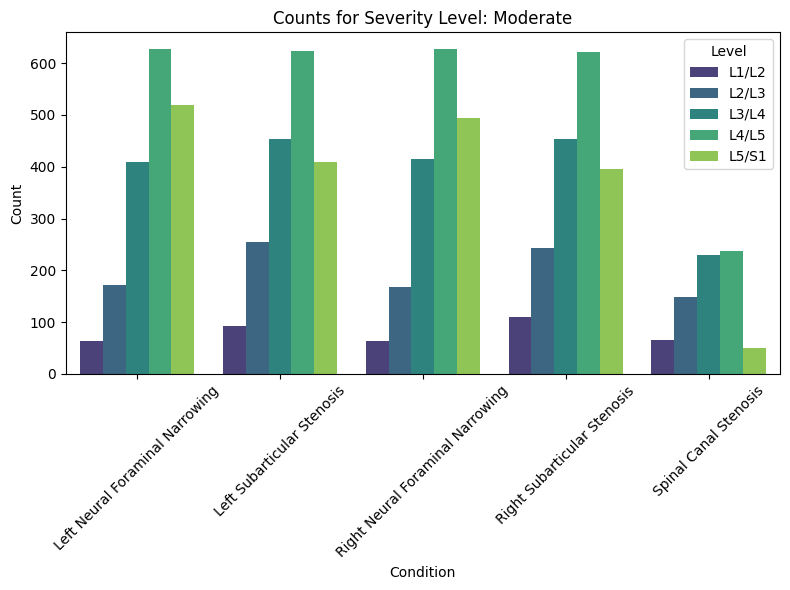

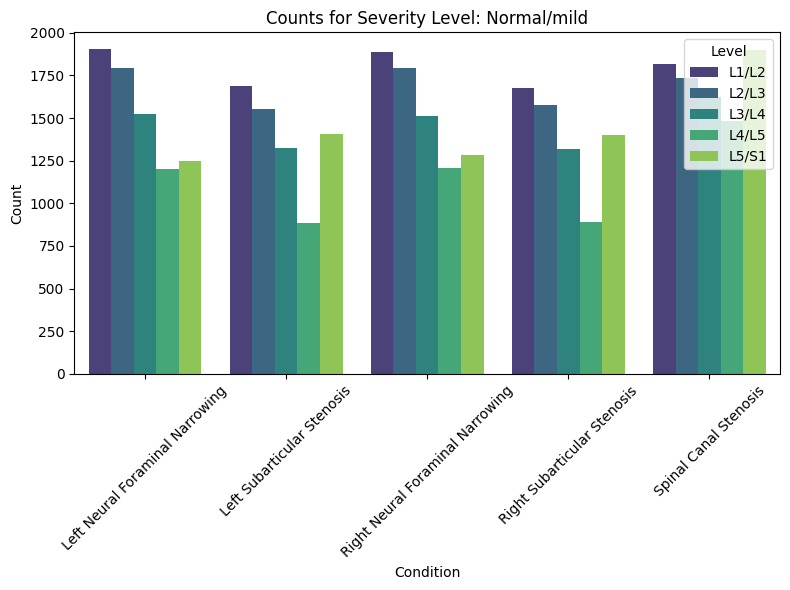

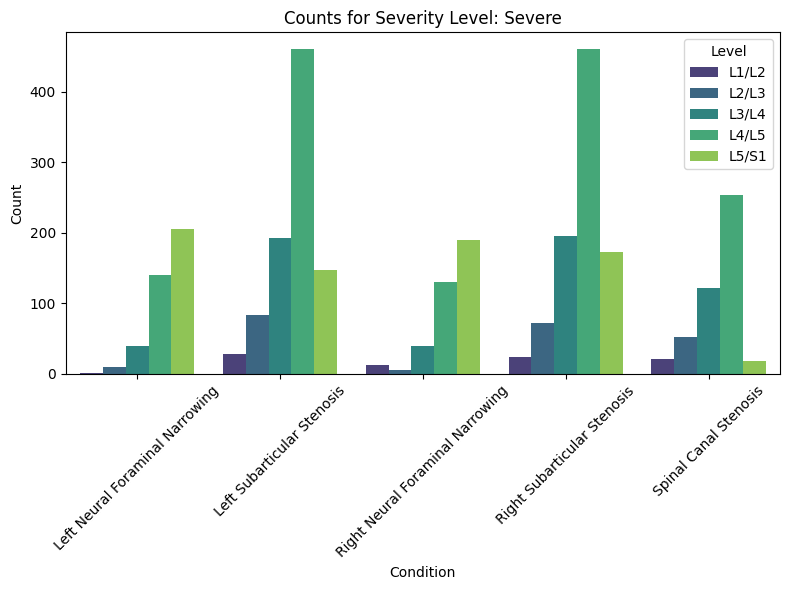

In [ ]:
grouped_df = final_merged_df.groupby(["condition", "level", "severity"]).size().reset_index(name="count")

# List of severity levels
severity_levels = grouped_df["severity"].unique()

# Create one plot per severity level
for severity in severity_levels:
    subset = grouped_df[grouped_df["severity"] == severity]

    # Pivot table to prepare for plotting
    pivot_df = subset.pivot(index="condition", columns="level", values="count").fillna(0)
    pivot_df = pivot_df[grouped_df["level"].unique()]  # Ensure consistent level order

    # Plot
    plt.figure(figsize=(8, 6))
    sns.barplot(data=subset, x="condition", y="count", hue="level", palette="viridis")
    plt.title(f"Counts for Severity Level: {severity.capitalize()}")
    plt.xlabel("Condition")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.legend(title="Level")
    plt.tight_layout()
    plt.show()

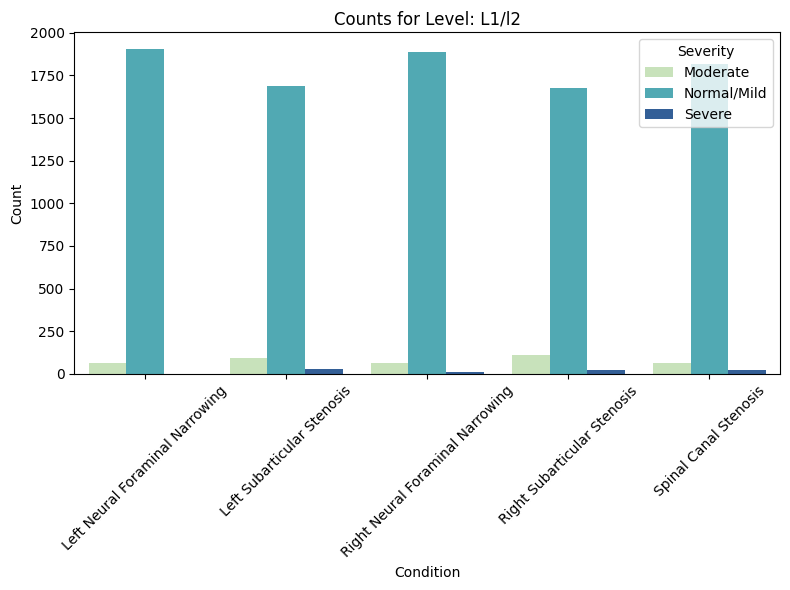

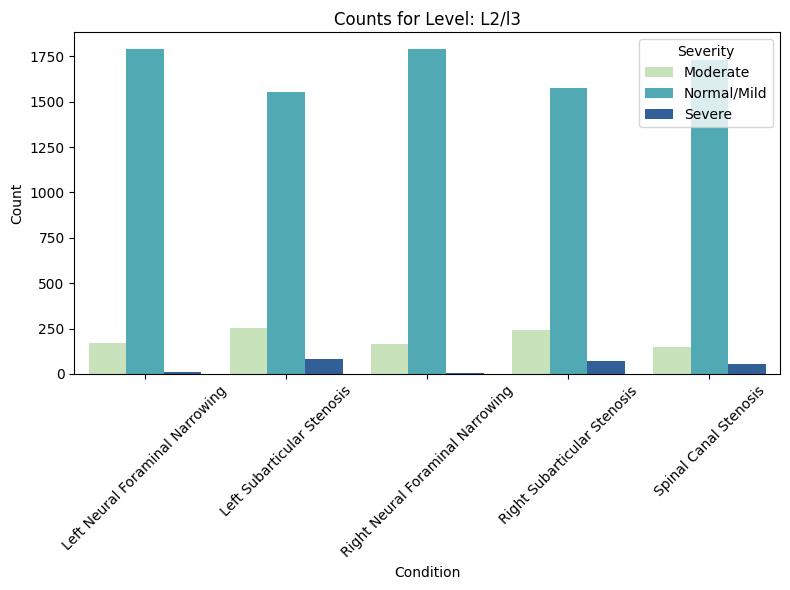

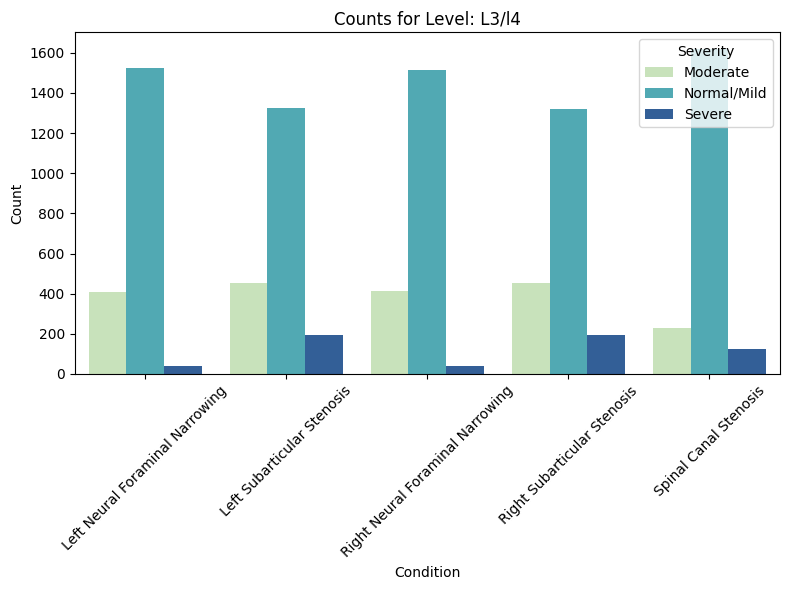

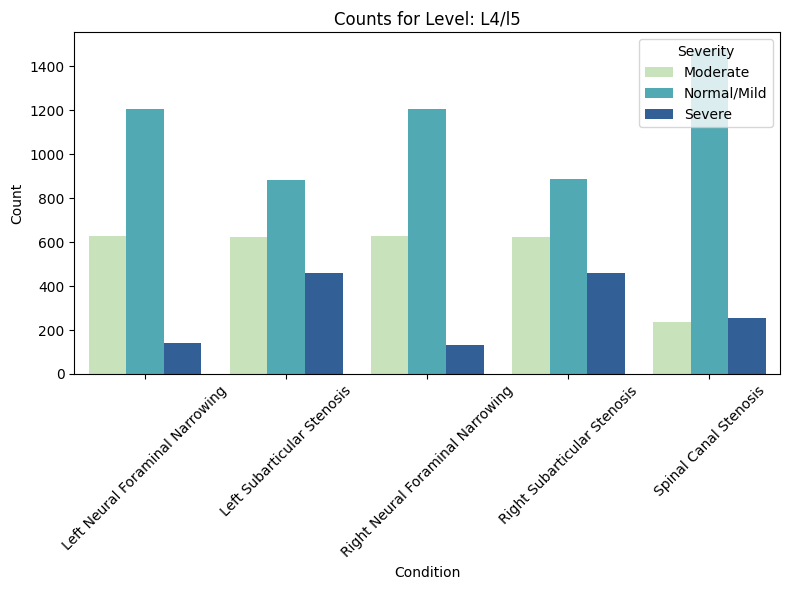

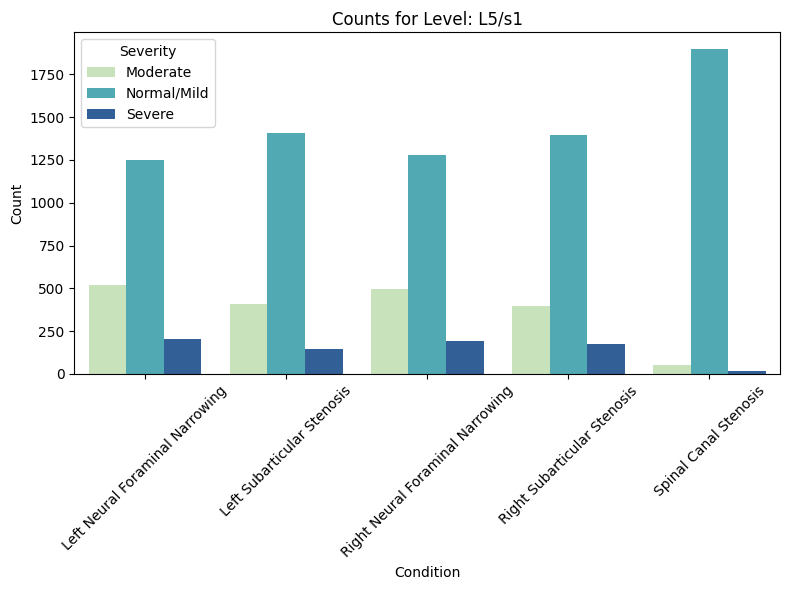

In [ ]:
grouped_df = final_merged_df.groupby(["condition", "level", "severity"]).size().reset_index(name="count")

# List of severity levels
levels = grouped_df["level"].unique()

# Create one plot per severity level
for level in levels:
    subset = grouped_df[grouped_df["level"] == level]

    # Pivot table to prepare for plotting
    pivot_df = subset.pivot(index="condition", columns="severity", values="count").fillna(0)
    pivot_df = pivot_df[grouped_df["severity"].unique()]  # Ensure consistent level order

    # Plot
    plt.figure(figsize=(8, 6))
    sns.barplot(data=subset, x="condition", y="count", hue="severity", palette="YlGnBu")
    plt.title(f"Counts for Level: {level.capitalize()}")
    plt.xlabel("Condition")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.legend(title="Severity")
    plt.tight_layout()
    plt.show()

In [ ]:
print(final_merged_df[final_merged_df["severity"] == "Normal/Mild"].value_counts().sum(), \
final_merged_df[final_merged_df["severity"] == "Moderate"].value_counts().sum(), \
final_merged_df[final_merged_df["severity"] == "Severe"].value_counts().sum())

37626 7950 3081


<ipython-input-16-0503b67fba04>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=final_merged_df, x="severity", palette="Set2")


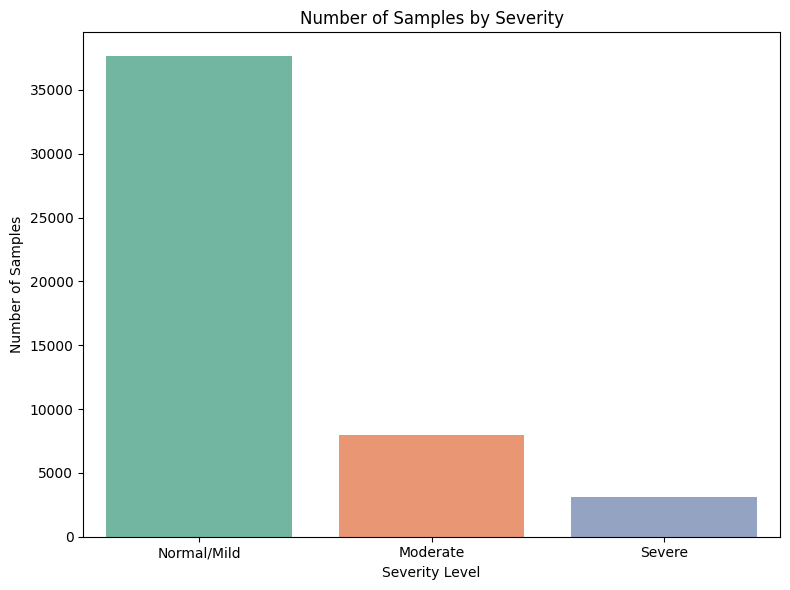

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the count plot for severity
plt.figure(figsize=(8, 6))
sns.countplot(data=final_merged_df, x="severity", palette="Set2")

# Add titles and labels
plt.title("Number of Samples by Severity")
plt.xlabel("Severity Level")
plt.ylabel("Number of Samples")

# Display the plot
plt.tight_layout()
plt.show()

In [ ]:
# Define the base path for test images
base_path = '/content/RSNAdata/test_images/'

# Function to get image paths for a series
def get_image_paths(row):
    series_path = os.path.join(base_path, str(row['study_id']), str(row['series_id']))
    if os.path.exists(series_path):
        return [os.path.join(series_path, f) for f in os.listdir(series_path) if os.path.isfile(os.path.join(series_path, f))]
    return []

# Mapping of series_description to conditions
condition_mapping = {
    'Sagittal T1': {'left': 'left_neural_foraminal_narrowing', 'right': 'right_neural_foraminal_narrowing'},
    'Axial T2': {'left': 'left_subarticular_stenosis', 'right': 'right_subarticular_stenosis'},
    'Sagittal T2/STIR': 'spinal_canal_stenosis'
}

# Create a list to store the expanded rows
expanded_rows = []

# Expand the dataframe by adding new rows for each file path
for index, row in test_desc.iterrows():
    image_paths = get_image_paths(row)
    conditions = condition_mapping.get(row['series_description'], {})
    if isinstance(conditions, str):  # Single condition
        conditions = {'left': conditions, 'right': conditions}
    for side, condition in conditions.items():
        for image_path in image_paths:
            expanded_rows.append({
                'study_id': row['study_id'],
                'series_id': row['series_id'],
                'series_description': row['series_description'],
                'image_path': image_path,
                'condition': condition,
                'row_id': f"{row['study_id']}_{condition}"
            })

# Create a new dataframe from the expanded rows
expanded_test_desc = pd.DataFrame(expanded_rows)

# Display the resulting dataframe
expanded_test_desc.head(5)

,study_id,series_id,series_description,image_path,condition,row_id
0,44036939,2828203845,Sagittal T1,/content/RSNAdata/test_images/44036939/2828203...,left_neural_foraminal_narrowing,44036939_left_neural_foraminal_narrowing
1,44036939,2828203845,Sagittal T1,/content/RSNAdata/test_images/44036939/2828203...,left_neural_foraminal_narrowing,44036939_left_neural_foraminal_narrowing
2,44036939,2828203845,Sagittal T1,/content/RSNAdata/test_images/44036939/2828203...,left_neural_foraminal_narrowing,44036939_left_neural_foraminal_narrowing
3,44036939,2828203845,Sagittal T1,/content/RSNAdata/test_images/44036939/2828203...,left_neural_foraminal_narrowing,44036939_left_neural_foraminal_narrowing
4,44036939,2828203845,Sagittal T1,/content/RSNAdata/test_images/44036939/2828203...,left_neural_foraminal_narrowing,44036939_left_neural_foraminal_narrowing


In [ ]:
# change severity column labels
#Normal/Mild': 'normal_mild', 'Moderate': 'moderate', 'Severe': 'severe'}
final_merged_df['severity'] = final_merged_df['severity'].map({'Normal/Mild': 'normal_mild', 'Moderate': 'moderate', 'Severe': 'severe'})

In [ ]:
full_test_data = expanded_test_desc
full_train_data = final_merged_df

In [ ]:
import os

# Define a function to check if a path exists
def check_exists(path):
    return os.path.exists(path)

# Define a function to check if a study ID directory exists
def check_study_id(row):
    study_id = row['study_id']
    path = f'{train_path}/train_images/{study_id}'
    return check_exists(path)

# Define a function to check if a series ID directory exists
def check_series_id(row):
    study_id = row['study_id']
    series_id = row['series_id']
    path = f'{train_path}/train_images/{study_id}/{series_id}'
    return check_exists(path)

# Define a function to check if an image file exists
def check_image_exists(row):
    image_path = row['image_path']
    return check_exists(image_path)

# Apply the functions to the train_data dataframe
full_train_data['study_id_exists'] = full_train_data.apply(check_study_id, axis=1)
full_train_data['series_id_exists'] = full_train_data.apply(check_series_id, axis=1)
full_train_data['image_exists'] = full_train_data.apply(check_image_exists, axis=1)

# Filter train_data
full_train_data = full_train_data[(full_train_data['study_id_exists']) & (full_train_data['series_id_exists']) & (full_train_data['image_exists'])]

In [ ]:
full_train_data.head(10)

,study_id,condition,level,severity,series_id,instance_number,x,y,series_description,row_id,image_path,study_id_exists,series_id_exists,image_exists
0,4003253,Spinal Canal Stenosis,L1/L2,normal_mild,702807833,8,322.831858,227.964602,Sagittal T2/STIR,4003253_spinal_canal_stenosis_l1_l2,/content/RSNAdata//train_images/4003253/702807...,True,True,True
1,4003253,Spinal Canal Stenosis,L2/L3,normal_mild,702807833,8,320.571429,295.714286,Sagittal T2/STIR,4003253_spinal_canal_stenosis_l2_l3,/content/RSNAdata//train_images/4003253/702807...,True,True,True
2,4003253,Spinal Canal Stenosis,L3/L4,normal_mild,702807833,8,323.030303,371.818182,Sagittal T2/STIR,4003253_spinal_canal_stenosis_l3_l4,/content/RSNAdata//train_images/4003253/702807...,True,True,True
3,4003253,Spinal Canal Stenosis,L4/L5,normal_mild,702807833,8,335.292035,427.327434,Sagittal T2/STIR,4003253_spinal_canal_stenosis_l4_l5,/content/RSNAdata//train_images/4003253/702807...,True,True,True
4,4003253,Spinal Canal Stenosis,L5/S1,normal_mild,702807833,8,353.415929,483.964602,Sagittal T2/STIR,4003253_spinal_canal_stenosis_l5_s1,/content/RSNAdata//train_images/4003253/702807...,True,True,True
5,4003253,Left Neural Foraminal Narrowing,L1/L2,normal_mild,1054713880,11,196.070671,126.021201,Sagittal T1,4003253_left_neural_foraminal_narrowing_l1_l2,/content/RSNAdata//train_images/4003253/105471...,True,True,True
6,4003253,Left Neural Foraminal Narrowing,L2/L3,normal_mild,1054713880,12,191.321555,170.120141,Sagittal T1,4003253_left_neural_foraminal_narrowing_l2_l3,/content/RSNAdata//train_images/4003253/105471...,True,True,True
7,4003253,Left Neural Foraminal Narrowing,L3/L4,normal_mild,1054713880,12,187.878354,217.245081,Sagittal T1,4003253_left_neural_foraminal_narrowing_l3_l4,/content/RSNAdata//train_images/4003253/105471...,True,True,True
8,4003253,Left Neural Foraminal Narrowing,L4/L5,moderate,1054713880,11,186.504472,251.592129,Sagittal T1,4003253_left_neural_foraminal_narrowing_l4_l5,/content/RSNAdata//train_images/4003253/105471...,True,True,True
9,4003253,Left Neural Foraminal Narrowing,L5/S1,normal_mild,1054713880,11,197.100569,289.457306,Sagittal T1,4003253_left_neural_foraminal_narrowing_l5_s1,/content/RSNAdata//train_images/4003253/105471...,True,True,True


In [ ]:
print(full_train_data.shape)
full_train_data = full_train_data.dropna()
print(full_train_data.shape)

(48692, 14)
(48657, 14)


In [ ]:
elevant_train_cols = ["study_id", "condition", "severity", "level", "image_path", "x", "y", "series_description"]
relevant_test_cols = ["study_id", "condition", "image_path", "series_description"]
# ["study_id", "condition", "level", "severity", etc.]
train_data = full_train_data[relevant_train_cols]
test_data = full_test_data[relevant_test_cols]
train_data.head(10)

,study_id,condition,severity,level,image_path,x,y,series_description
0,4003253,Spinal Canal Stenosis,normal_mild,L1/L2,/content/RSNAdata//train_images/4003253/702807...,322.831858,227.964602,Sagittal T2/STIR
1,4003253,Spinal Canal Stenosis,normal_mild,L2/L3,/content/RSNAdata//train_images/4003253/702807...,320.571429,295.714286,Sagittal T2/STIR
2,4003253,Spinal Canal Stenosis,normal_mild,L3/L4,/content/RSNAdata//train_images/4003253/702807...,323.030303,371.818182,Sagittal T2/STIR
3,4003253,Spinal Canal Stenosis,normal_mild,L4/L5,/content/RSNAdata//train_images/4003253/702807...,335.292035,427.327434,Sagittal T2/STIR
4,4003253,Spinal Canal Stenosis,normal_mild,L5/S1,/content/RSNAdata//train_images/4003253/702807...,353.415929,483.964602,Sagittal T2/STIR
5,4003253,Left Neural Foraminal Narrowing,normal_mild,L1/L2,/content/RSNAdata//train_images/4003253/105471...,196.070671,126.021201,Sagittal T1
6,4003253,Left Neural Foraminal Narrowing,normal_mild,L2/L3,/content/RSNAdata//train_images/4003253/105471...,191.321555,170.120141,Sagittal T1
7,4003253,Left Neural Foraminal Narrowing,normal_mild,L3/L4,/content/RSNAdata//train_images/4003253/105471...,187.878354,217.245081,Sagittal T1
8,4003253,Left Neural Foraminal Narrowing,moderate,L4/L5,/content/RSNAdata//train_images/4003253/105471...,186.504472,251.592129,Sagittal T1
9,4003253,Left Neural Foraminal Narrowing,normal_mild,L5/S1,/content/RSNAdata//train_images/4003253/105471...,197.100569,289.457306,Sagittal T1


## Image Processing Pipeline
DICOM images are loaded, normalized to 0-1 range, resized to 128x128, and converted to 3-channel format for compatibility with CNN architectures. A sample of 15,000 images is used for training due to memory constraints.

In [ ]:
def load_dicom_image(file_path, x_marker, y_marker, plane, condition, img_size=(128, 128)):
    # Read the DICOM file
    dicom = pydicom.dcmread(file_path)
    # dicom = pydicom.read_file(file_path)
    # Convert the DICOM file to a NumPy array
    img = dicom.pixel_array

    # scale x_marker and y_marker
    x_marker /= img.shape[0]
    y_marker /= img.shape[1]

    # print(img.shape) # (512, 512)
    # Cropping region of interest/level based on plane and condition:
    # if "Sagittal" in plane and "Narrowing" in condition:
    #     start_x = max(x_marker - 55, 0) # manually determined these crop constants after
    #     start_y = max(y_marker - 35, 0) # repeated sampling; need bounding box isolation
    #     end_x = min(x_marker + 56, img.shape[1]) # can be tweaked further
    #     end_y = min(y_marker + 36, img.shape[0])
    #     img = img[start_y:end_y, start_x:end_x]
    # Normalize the image (to 0-1 range)
    img = img / np.max(img)
    # Resize the image
    img_resized = cv2.resize(img, img_size)
    # Convert to 3-channel image (as we are using CNN architectures which require 3 channels)
    img_resized = np.stack((img_resized,)*3, axis=-1)
    return img_resized, (x_marker, y_marker)

def load_data_from_folders(data, img_size=(128, 128)):
    # spinal_canal_stenosis: 0 , left_neural_foraminal_narrowing: 1,
    # right_neural_foraminal_narrowing: 2, left_subarticular_stenosis: 3,
    # right_subarticular_stenosis:4
    X = []  # Image data
    X_metadata = [] # Meta data (x_marker, y_marker, and level)
    y = []  # Labels
    class_map = {"Spinal Canal Stenosis": 0 , "Left Neural Foraminal Narrowing": 1,
    "Right Neural Foraminal Narrowing": 2, "Left Subarticular Stenosis": 3,
    "Right Subarticular Stenosis": 4}
    severity_map = {"normal_mild": 0, "moderate": 1, "severe": 2}
    level_map = {'L1/L2': 0, 'L2/L3': 1, 'L3/L4': 2, 'L4/L5': 3, 'L5/S1': 4}
    crop_square_half_width = 10

    for index, row in data.iterrows():
        file_path = row['image_path']
        class_label = class_map[row['condition']]
        # print(row['severity'])
        severity_label = severity_map[row['severity']]
#         print(index, file_path)

        if file_path.endswith('.dcm'):
            try:
                # Load and preprocess the image
                x_marker = int(row['x'])
                y_marker = int(row['y'])
                level = level_map[row['level']]
                plane = row['series_description']
                cond = row['condition']
                img, (x_marker_scaled, y_marker_scaled) = load_dicom_image(file_path, x_marker, y_marker, plane, cond, img_size)
                # print(img.shape, x_center_marker, y_center_marker)
                X.append(img)
                X_metadata.append((x_marker_scaled, y_marker_scaled, level))
                y.append([class_label, severity_label])
            except Exception as e:
                print(f"Error loading {file_path}: {e}")
        else:
            break

    X = np.array(X)
    X_metadata = np.array(X_metadata)
    y = np.array(y)
    return X, X_metadata, y, class_map, severity_map

In [ ]:
def visualize_images(X, y, class_map, severity_map, num_images=5):
    cond_labels = {v: k for k, v in class_map.items()}
    sev_labels = {v: k for k, v in severity_map.items()}
    plt.figure(figsize=(10, 10))
    start_r = -min(num_images, len(X)) # 0
    end_r = 0 # min(num_images, len(X))
    for i in range(-min(num_images, len(X)), 0):
        plt.subplot(num_images, 1, i - start_r + 1)
        plt.imshow(X[i], cmap='gray')
        plt.title(cond_labels[y[i][0]] + ", " + sev_labels[y[i][1]])
        plt.axis('off')
    plt.show()

In [ ]:
tot_data = 15000
X, X_metadata, y, class_names, severity_names = load_data_from_folders(train_data.sample(tot_data, random_state=42))

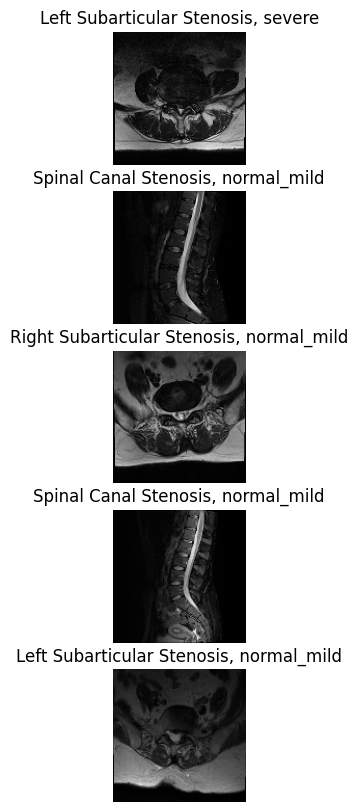

In [ ]:
visualize_images(X, y, class_names, severity_names)

In [ ]:
X.shape, y.shape

((15000, 128, 128, 3), (15000, 2))

In [ ]:
# print(y)
print(X.shape)
print(train_data.shape) # (48657, 7)
train_size = 0.7  #  for training
test_val_size = 0.3  #  for testing and validation
val_size = 0.5
test_size = 0.5

X_train, X_test_val, X_metadata_train, X_metadata_test_val, y_train, y_test_val = train_test_split(X, X_metadata, y, test_size=test_val_size, train_size=train_size, random_state=42)
X_val, X_test, X_metadata_val, X_metadata_test, y_val, y_test = train_test_split(X_test_val, X_metadata_test_val, y_test_val, test_size=test_size, train_size=val_size, random_state=42)

(15000, 128, 128, 3)
(48657, 8)


In [ ]:
print(type(X_train), X_train.shape, X_metadata_train.shape)
print(len(X_train), len(X_val), len(X_test)) # 70-15-15 train-val-test split

<class 'numpy.ndarray'> (10500, 128, 128, 3) (10500, 3)
10500 2250 2250


## Data Augmentation
To address class imbalance and improve generalization, we apply random augmentations including brightness/contrast adjustment, Gaussian noise, rotation, and grid distortion using the Albumentations library.

In [ ]:
import albumentations as A
import cv2

/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 1.4.22 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [ ]:
def normalize_image(image):
    """Normalize image to correct format for albumentations"""
    image = np.array(image)

    if image.dtype != np.uint8:
        if image.max() <= 1.0:
            image = (image * 255).astype(np.uint8)
        else:
            image = image.astype(np.uint8)
    if len(image.shape) == 2:
        image = np.expand_dims(image, axis=-1)

    return image

In [ ]:
def visualize_augmentations(X, y, class_map, severity_map, num_images=5, num_augmentations=5):
    transform = A.Compose([
        A.RandomBrightnessContrast(brightness_limit=(-0.1, 0.2), contrast_limit=0.2, p=0.6),
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.6),
        A.Rotate(limit=10, p=0.6),
        A.GridDistortion(num_steps=5, distort_limit=0.2, p=0.5),
        ##A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.5)
    ])
    cond_labels = {v: k for k, v in class_map.items()}
    sev_labels = {v: k for k, v in severity_map.items()}
    fig = plt.figure(figsize=(15, 4*num_images))

    for idx in range(min(num_images, len(X))):
        original_img = normalize_image(X[idx])

        plt.subplot(num_images, num_augmentations + 1, idx*(num_augmentations + 1) + 1)
        plt.imshow(original_img, cmap='gray')
        plt.title(f"Original\n{cond_labels[y[idx][0]]}\n{sev_labels[y[idx][1]]}", fontsize=8)
        plt.axis('off')

        for aug_idx in range(num_augmentations):
            augmented = transform(image=original_img)['image']
            plt.subplot(num_images, num_augmentations + 1, idx*(num_augmentations + 1) + aug_idx + 2)
            plt.imshow(augmented, cmap='gray')
            plt.title(f"Augmented {aug_idx + 1}", fontsize=8)
            plt.axis('off')
    plt.tight_layout()
    plt.show()

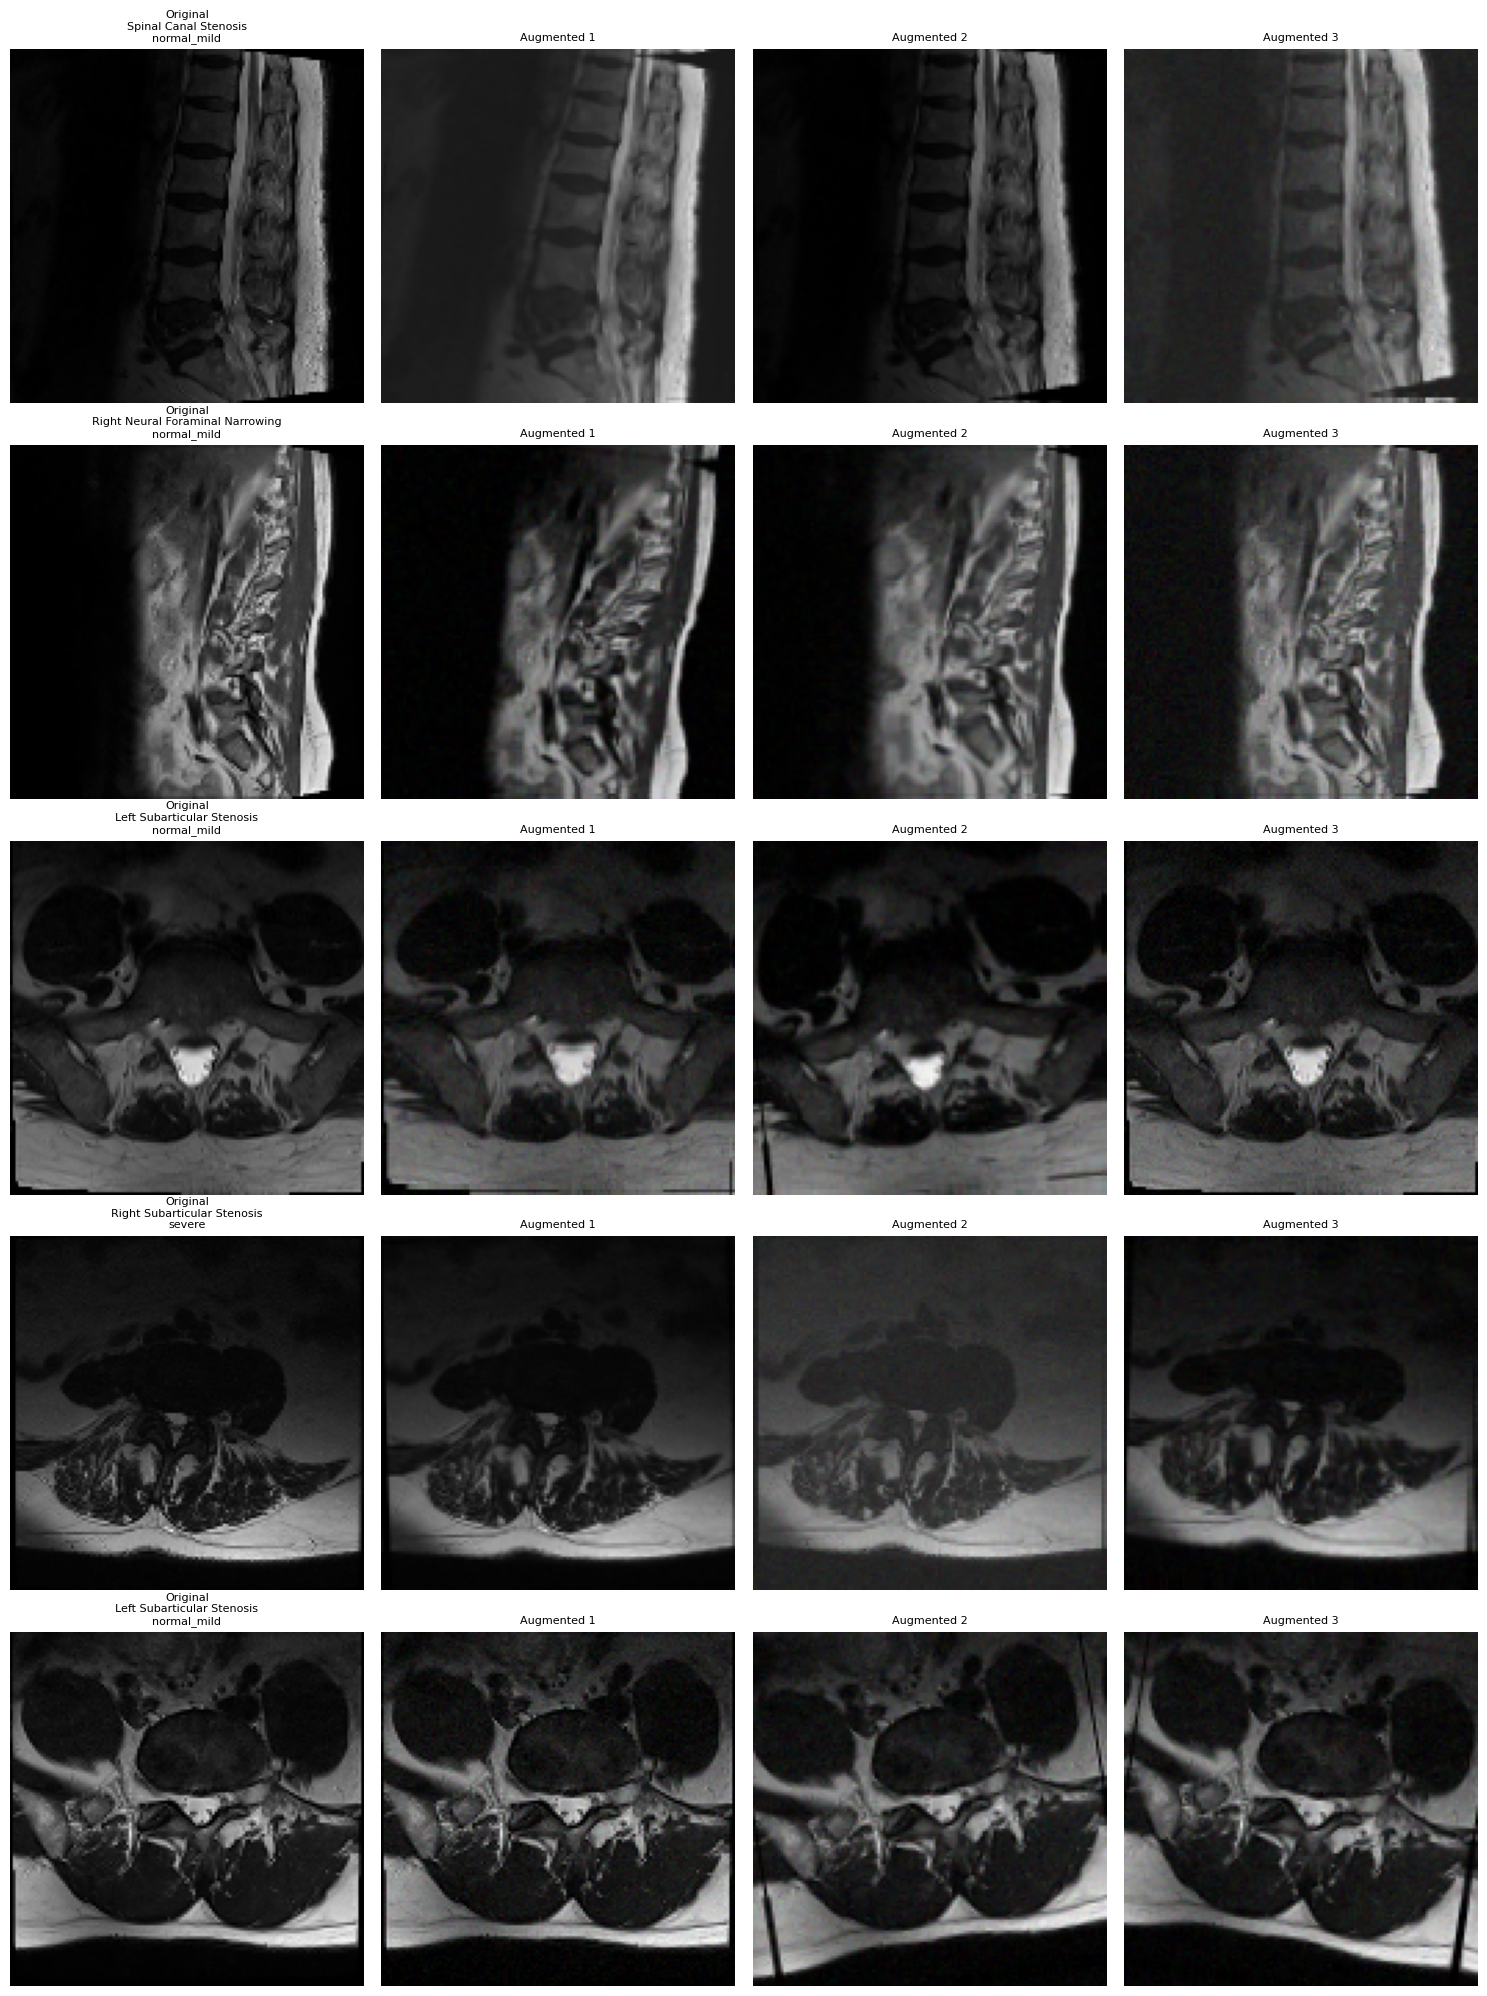

In [ ]:
visualize_augmentations(X, y, class_names, severity_names, num_images=5, num_augmentations=3)

In [ ]:
from tqdm import tqdm

In [ ]:
## now that we've tested, going to formally add these augmented images
def augment_dataset(X, X_metadata, y, num_augmentations=2):
    transform = A.Compose([
        A.RandomBrightnessContrast(brightness_limit=(-0.1, 0.2), contrast_limit=0.2, p=0.6),
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.6),
        A.Rotate(limit=10, p=0.6),
        A.GridDistortion(num_steps=5, distort_limit=0.2, p=0.5),
        ##A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.5)
    ])
    augmented_X = []
    augmented_X_metadata = []
    augmented_y = []

    for i in range(len(X)):
        augmented_X.append(X[i])
        augmented_X_metadata.append(X_metadata[i])
        augmented_y.append(y[i])

    print("Creating augmented images...")
    for i in tqdm(range(len(X))):
        img = normalize_image(X[i])
        for _ in range(num_augmentations):
            aug_img = transform(image=img)['image']
            if X[i].dtype != np.uint8:
                aug_img = aug_img.astype(X[i].dtype)
                if X[i].max() <= 1.0:
                    aug_img = aug_img / 255.0
            if len(X[i].shape) == 2:
                aug_img = aug_img.squeeze()
            augmented_X.append(aug_img)
            augmented_X_metadata.append(X_metadata[i])
            augmented_y.append(y[i])
    augmented_X = np.array(augmented_X)
    augmented_X_metadata = np.array(augmented_X_metadata)
    augmented_y = np.array(augmented_y)

    return augmented_X, augmented_X_metadata, augmented_y

In [ ]:
transforms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
    A.PixelDropout(dropout_prob=0.1, per_channel=True, p=0.5),
    A.CoarseDropout(num_holes_range=(3, 6),hole_height_range=(5, 10),
                    hole_width_range=(5, 10),
                    fill_value=0,
                    p=0.25),
    # A.GaussianBlur(p=0.2)
])

In [ ]:
y_train_cond = y_train[:, 0]  # Extract condition labels
y_train_sev = y_train[:, 1]   # Extract severity labels

# Repeat for validation data
y_val_cond = y_val[:, 0]
y_val_sev = y_val[:, 1]

In [ ]:
class AugmentedDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, X, X_metadata, y, batch_size=32, augment=True):
        """
        Initialize the data generator
        Args:
            X: Image data
            X_metadata: Metadata features
            y: Labels (should be a numpy array with shape (n_samples, 2))
            batch_size: Size of each batch
            augment: Whether to apply augmentation
        """
        super(AugmentedDataGenerator, self).__init__()
        self.X = X
        self.X_metadata = X_metadata
        self.y = y
        self.batch_size = batch_size
        self.augment = augment

        # Define augmentation pipeline
        self.transform = transforms

        self.indexes = np.arange(len(self.X))
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.X) / self.batch_size))

    def __getitem__(self, index):
        indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]

        # Preallocate arrays
        X_batch = np.empty((len(indexes), *self.X[0].shape), dtype=self.X.dtype)
        X_metadata_batch = np.empty((len(indexes), *self.X_metadata[0].shape), dtype=self.X_metadata.dtype)
        y_batch_condition = np.empty(len(indexes), dtype=self.y[:, 0].dtype)
        y_batch_severity = np.empty(len(indexes), dtype=self.y[:, 1].dtype)

        for i, idx in enumerate(indexes):
            image = self.X[idx]

            if self.augment and self.transform:
                # Normalize and augment
                image = (image * 255).astype(np.uint8) if image.max() <= 1 else image.astype(np.uint8)
                augmented = self.transform(image=image)['image']
                augmented = augmented.astype(self.X.dtype) / 255.0 if augmented.max() >= 1 else augmented
                X_batch[i] = augmented
            else:
                X_batch[i] = image

            X_metadata_batch[i] = self.X_metadata[idx]
            y_batch_condition[i] = self.y[idx, 0]
            y_batch_severity[i] = self.y[idx, 1]

        # Ensure the output is a tuple of inputs and outputs
        return (X_batch, X_metadata_batch), {'condition_output': y_batch_condition, 'severity_output': y_batch_severity}


    def on_epoch_end(self):
        np.random.shuffle(self.indexes)

## Model 1: Custom CNN
A custom convolutional neural network with dual output heads for simultaneous prediction of spinal condition (5 classes) and severity (3 classes). Trained with weighted loss functions to account for class imbalance.

In [ ]:
#Model declaration
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights_cond = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_cond),
    y=y_train_cond
)
class_weights_cond = dict(enumerate(class_weights_cond))

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input

# Define the learning rate schedule (before the model function)
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,  # Starting learning rate
    decay_steps=10000,           # Number of steps before decay
    decay_rate=0.9               # Decay rate (multiplier for each decay step)
)

# Define the custom CNN model with two outputs
def create_custom_cnn_model_with_severity(input_shape, num_classes_cond, num_classes_sev):
    input_layer = Input(shape=input_shape)

    x = layers.Conv2D(32, (5, 5), activation='relu', padding='same')(input_layer)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Flattening the output before fully connected layers
    x = layers.Flatten()(x)

    # Fully connected layers
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    # Output layers
    condition_output = layers.Dense(num_classes_cond, activation='softmax', name='condition_output')(x)
    severity_output = layers.Dense(num_classes_sev, activation='softmax', name='severity_output')(x)

    # Defining the model with two outputs
    model = models.Model(inputs=input_layer, outputs=[condition_output, severity_output])

    # Compile the model with optimizer and loss functions
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    model.compile(optimizer=optimizer,
                  loss={'condition_output': 'sparse_categorical_crossentropy',
                        'severity_output': 'sparse_categorical_crossentropy'},
                  loss_weights={'condition_output': 2.0, 'severity_output': 1.0},
                  metrics={'condition_output': 'accuracy', 'severity_output': 'accuracy'})

    return model

# Example input shape, number of condition and severity classes
input_shape = (128, 128, 3)  # Image size (128x128 pixels, 3 channels)
num_classes_cond = 5         # Example number of conditions
num_classes_sev = 3          # Example number of severity levels

# Create the model
model = create_custom_cnn_model_with_severity(input_shape, num_classes_cond, num_classes_sev)

# Get and print the model summary
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)         │ (None, 128, 128, 32)   │          2,432 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_9           │ (None, 64, 64, 32)     │              0 │ conv2d_9[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_10 (Conv2D)        │ (None, 62, 62, 64)     │         18,496 │ max_pooling2d_9[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_10          │ (None, 31, 31, 64)     │              0 │ conv2d_10[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_11 (Conv2D)        │ (None, 29, 29, 128)    │         73,856 │ max_pooling2d_10[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_11          │ (None, 14, 14, 128)    │              0 │ conv2d_11[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_3 (Flatten)       │ (None, 25088)          │              0 │ max_pooling2d_11[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_6 (Dense)           │ (None, 128)            │      3,211,392 │ flatten_3[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_6 (Dropout)       │ (None, 128)            │              0 │ dense_6[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_7 (Dense)           │ (None, 64)             │          8,256 │ dropout_6[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_7 (Dropout)       │ (None, 64)             │              0 │ dense_7[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ condition_output (Dense)  │ (None, 5)              │            325 │ dropout_7[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ severity_output (Dense)   │ (None, 3)              │            195 │ dropout_7[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 3,314,952 (12.65 MB)

 Trainable params: 3,314,952 (12.65 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
train_generator = AugmentedDataGenerator(
    X_train,
    X_metadata_train,
    y_train,
    batch_size=16,
    augment=True
)

val_generator = AugmentedDataGenerator(
    X_val,
    X_metadata_val,
    y_val,
    batch_size=16,
    augment=False,  # No augmentation for validation
)

In [ ]:
model.compile(
    optimizer='adam',
    loss={
        'condition_output': 'sparse_categorical_crossentropy',
        'severity_output': 'sparse_categorical_crossentropy'
    },
    metrics={
        'condition_output': 'accuracy',
        'severity_output': 'accuracy'
    }
)

In [ ]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    [X_train, X_metadata_train],  # Inputs: images and metadata
    {
        'condition_output': y_train_cond,
        'severity_output': y_train_sev
    },  # Outputs
    validation_data=(
        [X_val, X_metadata_val],  # Validation inputs
        {
            'condition_output': y_val_cond,
            'severity_output': y_val_sev
        }
    ),
    epochs=40,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/40
329/329 ━━━━━━━━━━━━━━━━━━━━ 23s 38ms/step - condition_output_accuracy: 0.4548 - condition_output_loss: 1.1423 - loss: 1.8759 - severity_output_accuracy: 0.7582 - severity_output_loss: 0.7335 - val_condition_output_accuracy: 0.5813 - val_condition_output_loss: 0.6122 - val_loss: 1.1585 - val_severity_output_accuracy: 0.7929 - val_severity_output_loss: 0.5463 - learning_rate: 0.0010
Epoch 2/40
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - condition_output_accuracy: 0.5863 - condition_output_loss: 0.6589 - loss: 1.2664 - severity_output_accuracy: 0.7798 - severity_output_loss: 0.6075 - val_condition_output_accuracy: 0.5876 - val_condition_output_loss: 0.5904 - val_loss: 1.1200 - val_severity_output_accuracy: 0.7929 - val_severity_output_loss: 0.5305 - learning_rate: 0.0010
Epoch 3/40
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - condition_output_accuracy: 0.6054 - condition_output_loss: 0.6083 - loss: 1.1817 - severity_output_accuracy: 0.7794 - severity_output_loss: 0.5734 - val_c

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Extract accuracy for each output
    cond_acc = history.history['condition_output_accuracy']
    val_cond_acc = history.history['val_condition_output_accuracy']
    sev_acc = history.history['severity_output_accuracy']
    val_sev_acc = history.history['val_severity_output_accuracy']

    # Extract total loss
    total_loss = history.history['loss']
    val_total_loss = history.history['val_loss']

    epochs = range(1, len(cond_acc) + 1)

    # Plot accuracy for each output
    plt.figure(figsize=(15, 6))

    # Condition Output Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, cond_acc, 'b', marker='o', label='Training Accuracy - Condition')
    plt.plot(epochs, val_cond_acc, 'c', marker='x', label='Validation Accuracy - Condition')
    plt.title('Condition Output Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Severity Output Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, sev_acc, 'b', marker='o', label='Training Accuracy - Severity')
    plt.plot(epochs, val_sev_acc, 'c', marker='x', label='Validation Accuracy - Severity')
    plt.title('Severity Output Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot total loss
    plt.figure(figsize=(7, 5))
    plt.plot(epochs, total_loss, 'b', marker='o', label='Training Loss')
    plt.plot(epochs, val_total_loss, 'c', marker='x', label='Validation Loss')
    plt.title('Total Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()


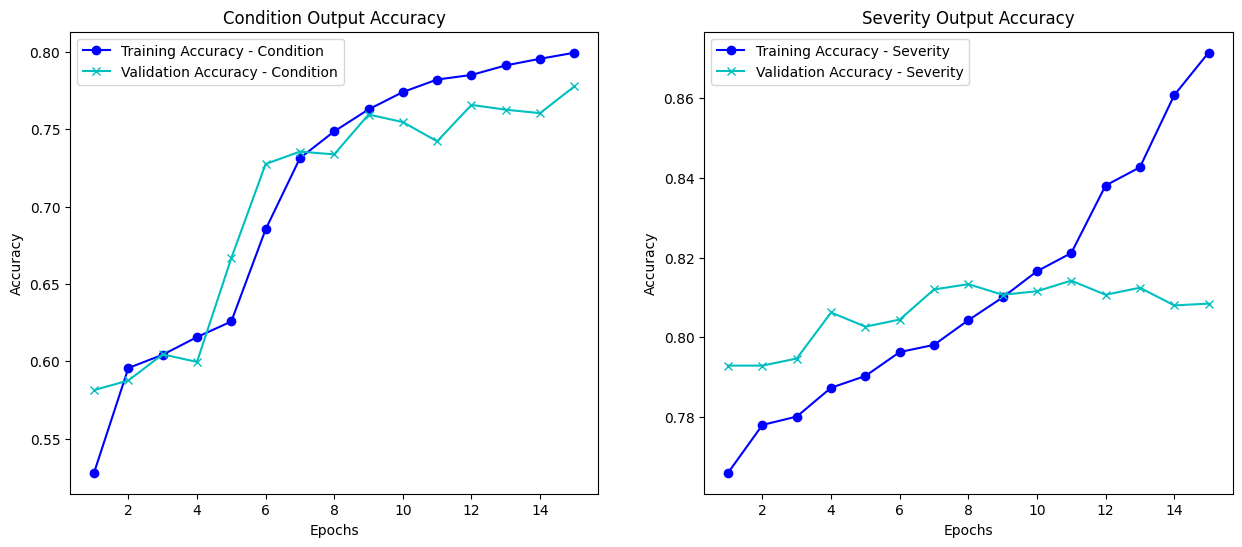

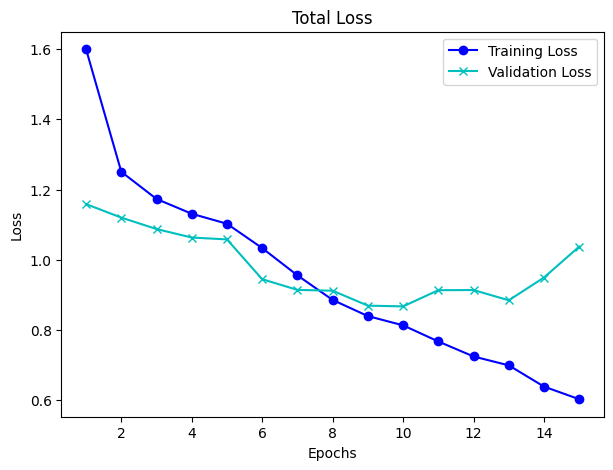

In [ ]:
# Call the function after training
plot_training_history(history)

In [ ]:
# Assuming y_test contains both outputs in separate columns
y_test_cond = y_test[:, 0]  # Condition labels
y_test_sev = y_test[:, 1]   # Severity labels

# Evaluate the model again
test_loss, cond_test_acc, sev_test_acc = model.evaluate(
    [X_test, X_metadata_test],
    {'condition_output': y_test_cond, 'severity_output': y_test_sev}
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy - Condition Output: {cond_test_acc:.4f}")
print(f"Test Accuracy - Severity Output: {sev_test_acc:.4f}")

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - condition_output_accuracy: 0.7516 - condition_output_loss: 0.3994 - loss: 0.9391 - severity_output_accuracy: 0.7912 - severity_output_loss: 0.5396


ValueError: too many values to unpack (expected 3)

## Model 2: Fine-tuned VGG16
A pre-trained VGG16 model fine-tuned on the RSNA dataset with separate dense branches for condition and severity prediction. The last 5 layers are unfrozen for domain adaptation. This model outperformed the custom CNN on both tasks.

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, Input

def create_vgg_cnn_model_with_separate_branches(input_shape, input_metadata_shape, num_classes_cond, num_classes_sev, fine_tune=True, num_layers_fine_tune=5):
    # Input layers
    input_layer = Input(shape=input_shape)
    input_metadata_layer = Input(shape=input_metadata_shape)

    # Base model for feature extraction
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    if fine_tune:
        for layer in base_model.layers[:-num_layers_fine_tune]:  # Freeze all but last layers
            layer.trainable = False
    else:
        base_model.trainable = False

    # Shared feature extraction
    shared_features = base_model(input_layer)
    shared_features = layers.Flatten()(shared_features)
    shared_features = layers.Concatenate()([shared_features, input_metadata_layer])

    # Branch for condition-specific features
    x_cond = layers.Dense(512, activation='relu')(shared_features)
    x_cond = layers.Dropout(0.3)(x_cond)
    x_cond = layers.Dense(256, activation='relu')(x_cond)
    x_cond = layers.Dropout(0.3)(x_cond)
    condition_output = layers.Dense(num_classes_cond, activation='softmax', name='condition_output')(x_cond)

    # Branch for severity-specific features
    x_sev = layers.Dense(512, activation='relu')(shared_features)
    x_sev = layers.Dropout(0.3)(x_sev)
    x_sev = layers.Dense(256, activation='relu')(x_sev)
    x_sev = layers.Dropout(0.3)(x_sev)
    severity_output = layers.Dense(num_classes_sev, activation='softmax', name='severity_output')(x_sev)

    # Create the model
    model = models.Model(inputs=[input_layer, input_metadata_layer], outputs=[condition_output, severity_output])

    # Compile the model with appropriate loss weights
    model.compile(
        optimizer='adam',
        loss={
            'condition_output': 'sparse_categorical_crossentropy',
            'severity_output': 'sparse_categorical_crossentropy',
        },
        loss_weights={
            'condition_output': 1.0,  # Weight condition more heavily
            'severity_output': 2.0,
        },
        metrics={
            'condition_output': 'accuracy',
            'severity_output': 'accuracy',
        }
    )
    return model

In [ ]:
# Define shapes
input_shape = (128, 128, 3)  # Example: Images are 128x128 with 3 color channels
input_metadata_shape = (3,)  # Example: 3 metadata features

# Define number of classes
num_cond_classes = len(class_names)  # Total condition classes
num_sev_classes = len(severity_names)  # Total severity classes

# Create model
model = create_vgg_cnn_model_with_separate_branches(
    input_shape=input_shape,
    input_metadata_shape=input_metadata_shape,
    num_classes_cond=num_cond_classes,
    num_classes_sev=num_sev_classes,
    fine_tune=True,
    num_layers_fine_tune=5
)

# Check model summary
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ vgg16 (Functional)        │ (None, 4, 4, 512)      │     14,714,688 │ input_layer_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_5 (Flatten)       │ (None, 8192)           │              0 │ vgg16[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_5             │ (None, 3)              │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_1             │ (None, 8195)           │              0 │ flatten_5[0][0],       │
│ (Concatenate)             │                        │                │ input_layer_5[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_12 (Dense)          │ (None, 512)            │      4,196,352 │ concatenate_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_14 (Dense)          │ (None, 512)            │      4,196,352 │ concatenate_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_10 (Dropout)      │ (None, 512)            │              0 │ dense_12[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_12 (Dropout)      │ (None, 512)            │              0 │ dense_14[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_13 (Dense)          │ (None, 256)            │        131,328 │ dropout_10[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_15 (Dense)          │ (None, 256)            │        131,328 │ dropout_12[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_11 (Dropout)      │ (None, 256)            │              0 │ dense_13[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_13 (Dropout)      │ (None, 256)            │              0 │ dense_15[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ condition_output (Dense)  │ (None, 5)              │          1,285 │ dropout_11[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ severity_output (Dense)   │ (None, 3)              │            771 │ dropout_13[0][0]       │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 23,372,104 (89.16 MB)

 Trainable params: 15,736,840 (60.03 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

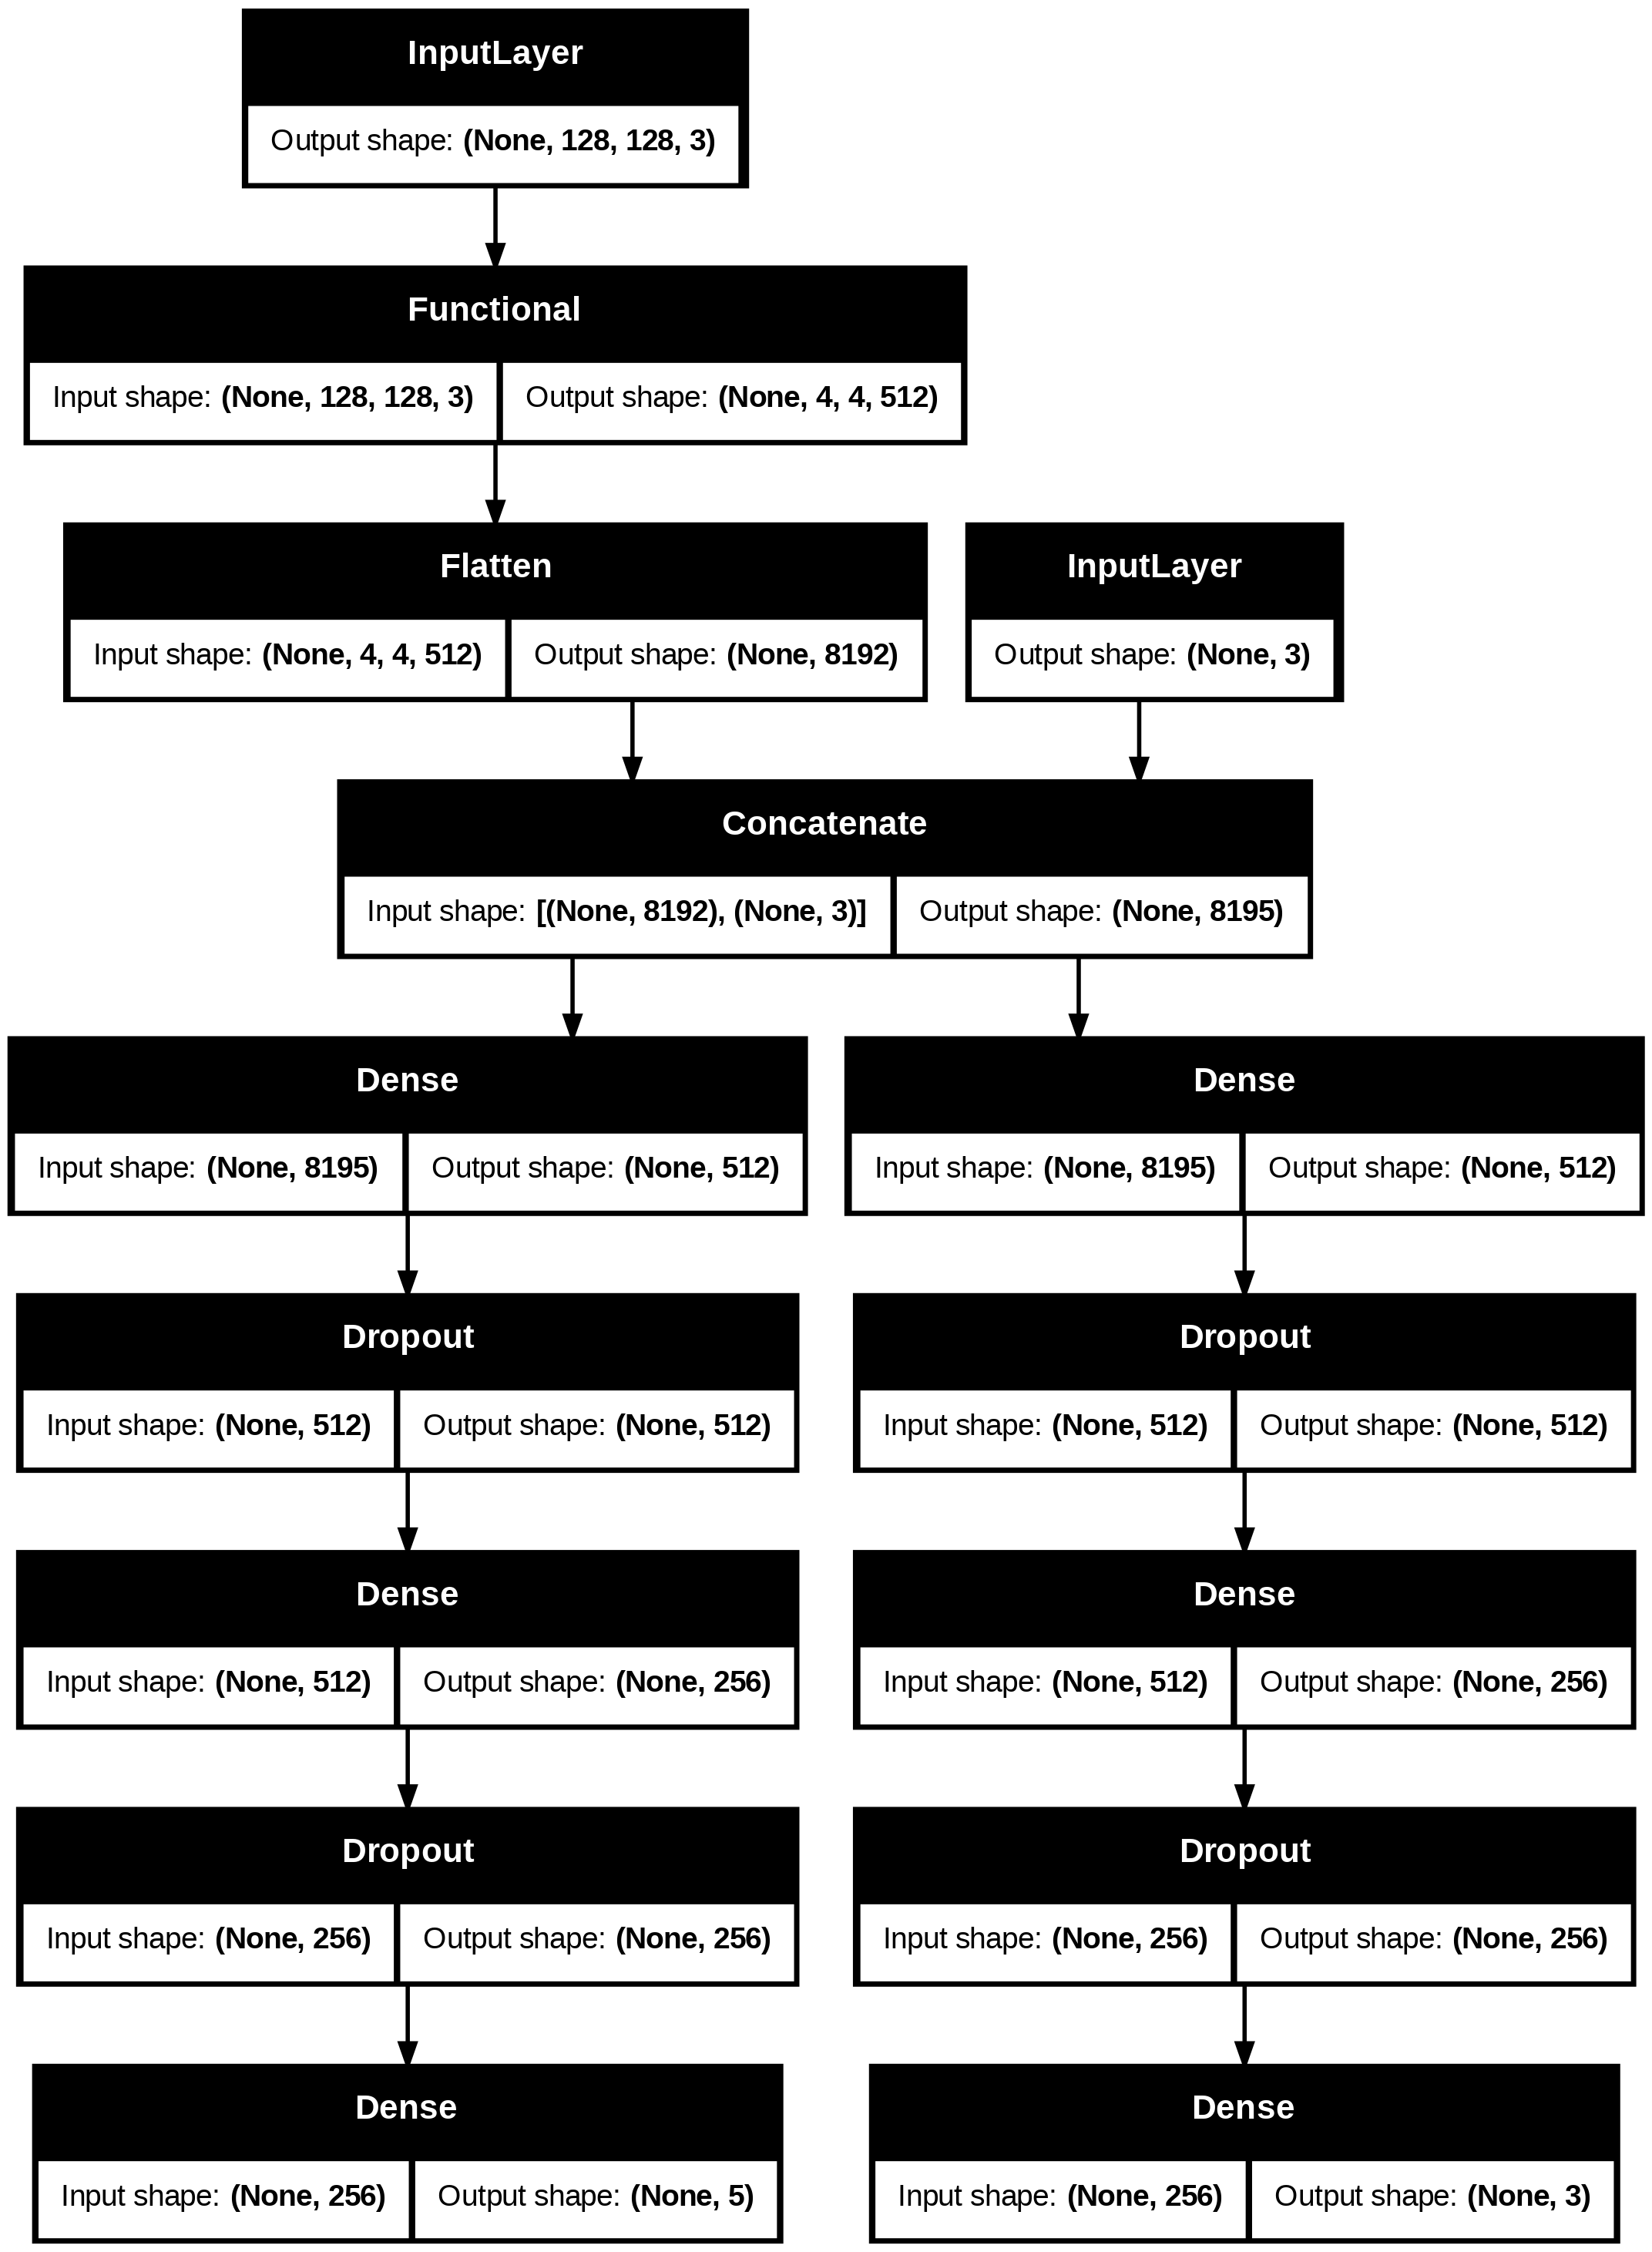

In [ ]:
from keras.utils import plot_model

plot_model(model, to_file='model.png', show_shapes=True)

In [ ]:
tf.config.list_physical_devices('GPU') # Verify that GPU will be used

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
train_generator = AugmentedDataGenerator(
    X_train,
    X_metadata_train,
    y_train,
    batch_size=16,
    augment=True
)

val_generator = AugmentedDataGenerator(
    X_val,
    X_metadata_val,
    y_val,
    batch_size=16,
    augment=False,  # No augmentation for validation
)

In [ ]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
early_stopping = EarlyStopping(monitor='val_loss', patience=5)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=40,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/40
656/656 ━━━━━━━━━━━━━━━━━━━━ 33s 33ms/step - condition_output_accuracy: 0.4598 - condition_output_loss: 1.0180 - loss: 2.4275 - severity_output_accuracy: 0.7745 - severity_output_loss: 1.4094 - val_condition_output_accuracy: 0.6004 - val_condition_output_loss: 0.5801 - val_loss: 1.6475 - val_severity_output_accuracy: 0.7964 - val_severity_output_loss: 1.0674 - learning_rate: 0.0010
Epoch 2/40
656/656 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - condition_output_accuracy: 0.5885 - condition_output_loss: 0.6048 - loss: 1.7611 - severity_output_accuracy: 0.7788 - severity_output_loss: 1.1562 - val_condition_output_accuracy: 0.5911 - val_condition_output_loss: 0.5721 - val_loss: 1.6645 - val_severity_output_accuracy: 0.7969 - val_severity_output_loss: 1.0923 - learning_rate: 0.0010
Epoch 3/40
656/656 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - condition_output_accuracy: 0.5944 - condition_output_loss: 0.6148 - loss: 1.7162 - severity_output_accuracy: 0.7845 - severity_output_loss: 1.1014 - val

In [ ]:
def plot_training_history(history):
    # Extract accuracy for each output
    cond_acc = history.history['condition_output_accuracy']
    val_cond_acc = history.history['val_condition_output_accuracy']
    sev_acc = history.history['severity_output_accuracy']
    val_sev_acc = history.history['val_severity_output_accuracy']

    # Extract total loss
    total_loss = history.history['loss']
    val_total_loss = history.history['val_loss']

    epochs = range(1, len(cond_acc) + 1)

    # Plot accuracy for each output
    plt.figure(figsize=(15, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, cond_acc, 'g', label='Condition Training Accuracy')
    plt.plot(epochs, val_cond_acc, 'r', label='Condition Validation Accuracy')
    plt.title('Condition Output Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, sev_acc, 'g', label='Severity Training Accuracy')
    plt.plot(epochs, val_sev_acc, 'r', label='Severity Validation Accuracy')
    plt.title('Severity Output Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot total loss
    plt.figure(figsize=(7, 5))
    plt.plot(epochs, total_loss, 'g', label='Total Training Loss')
    plt.plot(epochs, val_total_loss, 'r', label='Total Validation Loss')
    plt.title('Total Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

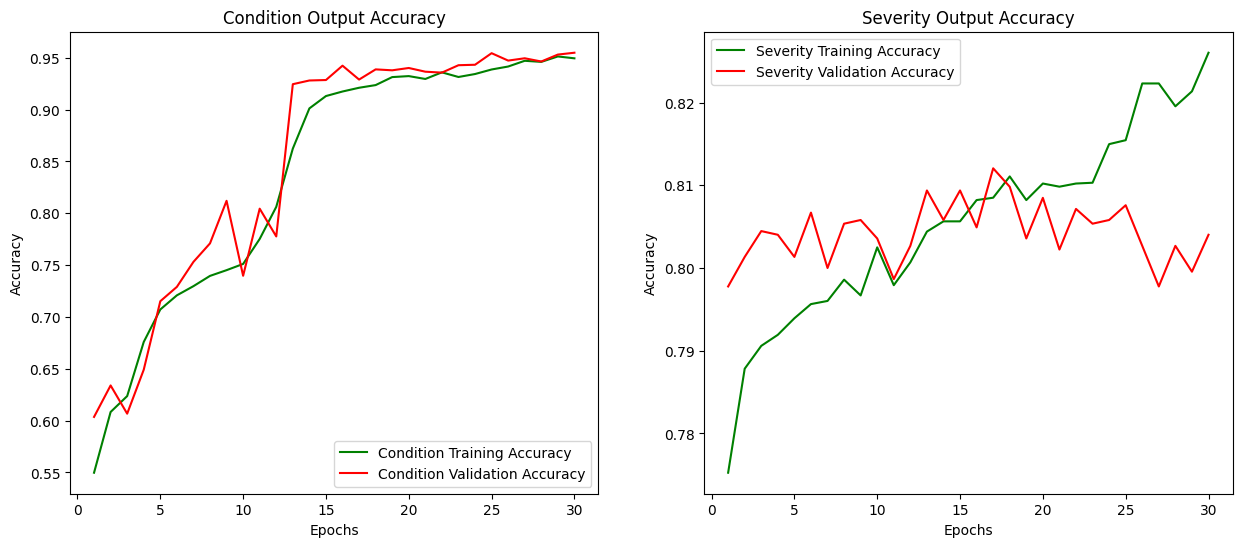

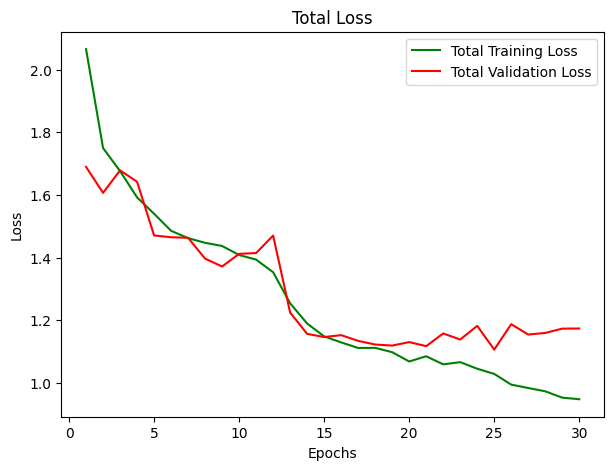

In [ ]:
plot_training_history(history)

In [ ]:
condition_preds, severity_preds = model.predict([X_test, X_metadata_test])
condition_label_preds = np.argmax(condition_preds, axis=1)
severity_label_preds = np.argmax(severity_preds, axis=1)

71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step


In [ ]:
# Sanity checks
print(np.unique(condition_label_preds), np.unique(severity_label_preds))
print(condition_label_preds.shape)
print(severity_label_preds.shape)

[0 1 2 3 4] [0 1 2]
(2250,)
(2250,)


## Evaluation and Results
Evaluating both models on the held-out test set using accuracy, precision, recall, and F1 score. The VGG16 model achieved 95% accuracy on condition classification and 79% accuracy on severity classification.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def calculate_precision(y_true, y_pred):
    return precision_score(y_true, y_pred, average='weighted')

def calculate_recall(y_true, y_pred):
    return recall_score(y_true, y_pred, average='weighted')

def calculate_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average='weighted')

def calculate_accuracy(y_true, y_pred):
    return accuracy_score(y_true, y_pred)

y_test_condition = y_test[:, 0]
y_test_severity = y_test[:, 1]

condition_precision = calculate_precision(y_test_condition, condition_label_preds)
condition_recall = calculate_recall(y_test_condition, condition_label_preds)
condition_f1 = calculate_f1(y_test_condition, condition_label_preds)
condition_accuracy = calculate_accuracy(y_test_condition, condition_label_preds)

severity_precision = calculate_precision(y_test_severity, severity_label_preds)
severity_recall = calculate_recall(y_test_severity, severity_label_preds)
severity_f1 = calculate_f1(y_test_severity, severity_label_preds)
severity_accuracy = calculate_accuracy(y_test_severity, severity_label_preds)

print(f"Condition Accuracy: {condition_accuracy:.4f}")
print(f"Condition Precision: {condition_precision:.4f}")
print(f"Condition Recall: {condition_recall:.4f}")
print(f"Condition F1 Score: {condition_f1:.4f}")
print()
print(f"Severity Accuracy: {severity_accuracy:.4f}")
print(f"Severity Precision: {severity_precision:.4f}")
print(f"Severity Recall: {severity_recall:.4f}")
print(f"Severity F1 Score: {severity_f1:.4f}")

Condition Accuracy: 0.9404
Condition Precision: 0.9407
Condition Recall: 0.9404
Condition F1 Score: 0.9404

Severity Accuracy: 0.7853
Severity Precision: 0.7473
Severity Recall: 0.7853
Severity F1 Score: 0.7543
